# KNN + PCA Classification — POC-ABS Features

Pipeline:
1. Load `poc_abs_flatten.xlsx` (per-frame, 393 features)
2. Analisis PCA → n_components optimal
3. Pisahkan external test set (per-subject)
4. Train via `build_pca_knn()` — Pipeline(Scaler → PCA → KNN balanced)
5. Split 60/40, 70/30, 80/20, 90/10
6. Metrik: UF1 (macro F1), UAR (macro recall), accuracy
7. External test


In [ ]:
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "comparasion":
    ROOT = ROOT.parent
elif ROOT.name in {"lstm", "svm", "knn"}:
    ROOT = ROOT.parent.parent.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from comparasion.core.models import build_pca_knn, fit_model, predict

## 1. Load Data

In [ ]:
FEATURE_PATH = Path("comparasion/output_casme2//features/poc_abs_flatten.xlsx")

df = pd.read_excel(FEATURE_PATH)
print(f"Shape: {df.shape}")

META_COLS = ["emotion", "subject", "clip", "frame", "label"]
feat_cols = [c for c in df.columns if c not in META_COLS]

print(f"Features: {len(feat_cols)}")
print(f"\nLabel dist:")
print(df["label"].value_counts())

Shape: (1151, 613)
Features: 608

Label dist:
label
Surprise     324
Happiness    305
Sadness      267
Disgust      255
Name: count, dtype: int64


## 2. External Test Set

In [ ]:
SEED = 42

le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])
print(f"Classes: {list(le.classes_)}")

rng = np.random.RandomState(SEED)
external_subjects = set()

for emo in df["emotion"].unique():
    subjects_in_emo = df[df["emotion"] == emo]["subject"].unique()
    n_ext = min(2, len(subjects_in_emo))
    chosen = rng.choice(subjects_in_emo, size=n_ext, replace=False)
    external_subjects.update(chosen)

print(f"External subjects ({len(external_subjects)}): {sorted(external_subjects)}")

df_ext = df[df["subject"].isin(external_subjects)].copy()
df_main = df[~df["subject"].isin(external_subjects)].copy()

print(f"\nMain: {len(df_main)} rows")
print(f"External: {len(df_ext)} rows")

Classes: ['Disgust', 'Happiness', 'Sadness', 'Surprise']
External subjects (7): [np.int64(5), np.int64(6), np.int64(14), np.int64(17), np.int64(19), np.int64(20), np.int64(24)]

Main: 344 rows
External: 807 rows


In [ ]:
X_main = df_main[feat_cols].values
y_main = df_main["label_enc"].values

X_ext = df_ext[feat_cols].values
y_ext = df_ext["label_enc"].values

print(f"X_main: {X_main.shape}  ({X_main.shape[1]} features)")
print(f"X_ext:  {X_ext.shape}")

X_main: (344, 608)  (608 features)
X_ext:  (807, 608)


## 3. Analisis PCA

Scale → PCA full → cari n_components untuk 90% dan 95% variance.


In [ ]:
scaler_tmp = StandardScaler()
X_scaled = scaler_tmp.fit_transform(X_main)

pca_full = PCA()
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1

print(f"90% variance: {n_90} komponen")
print(f"95% variance: {n_95} komponen")
print(f"Total: {len(cumvar)}")

90% variance: 156 komponen
95% variance: 196 komponen
Total: 344


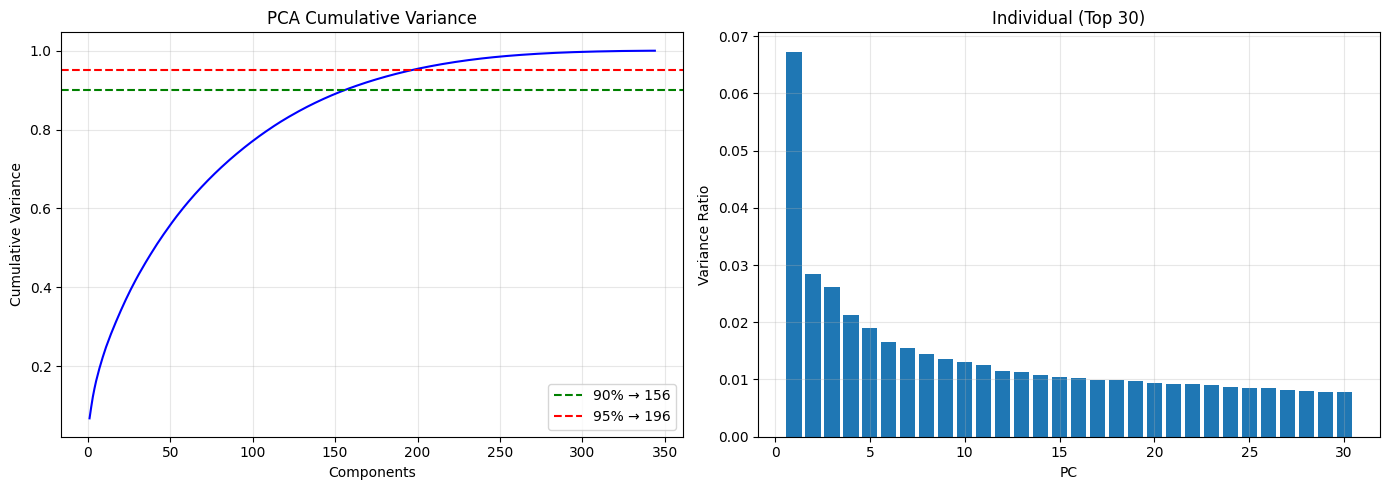

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(cumvar) + 1), cumvar, "b-")
axes[0].axhline(y=0.90, color="g", ls="--", label=f"90% → {n_90}")
axes[0].axhline(y=0.95, color="r", ls="--", label=f"95% → {n_95}")
axes[0].set_xlabel("Components"); axes[0].set_ylabel("Cumulative Variance")
axes[0].set_title("PCA Cumulative Variance"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

top_n = min(30, len(pca_full.explained_variance_ratio_))
axes[1].bar(range(1, top_n + 1), pca_full.explained_variance_ratio_[:top_n])
axes[1].set_xlabel("PC"); axes[1].set_ylabel("Variance Ratio")
axes[1].set_title(f"Individual (Top {top_n})"); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Training KNN + PCA — Tiap Split Terpisah

`build_pca_knn(n_components)` = `Pipeline([StandardScaler, PCA, SVC(rbf, balanced)])`


In [ ]:
N_COMPONENTS = n_95
print(f"Using PCA n_components = {N_COMPONENTS}")

Using PCA n_components = 196


### Split 60/40

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.4, stratify=y_main, random_state=SEED
)

pipe = build_pca_knn(n_components=N_COMPONENTS)
res = fit_model(pipe, X_tr, y_tr, model_name="KNN_PCA_60/40")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"PCA: {X_tr.shape[1]} → {N_COMPONENTS} features")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_60_40 = {
    "split": "60/40", "test_size": 0.4,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 206 rows, Val: 138 rows
PCA: 608 → 196 features
Train — Acc: 1.0000  UF1: 1.0000  UAR: 1.0000
Val   — Acc: 0.8913  UF1: 0.9006  UAR: 0.8919

              precision    recall  f1-score   support

     Disgust       0.92      0.78      0.85        46
   Happiness       0.85      0.97      0.90        58
     Sadness       1.00      0.88      0.93        16
    Surprise       0.89      0.94      0.92        18

    accuracy                           0.89       138
   macro avg       0.92      0.89      0.90       138
weighted avg       0.90      0.89      0.89       138



### Split 70/30

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.3, stratify=y_main, random_state=SEED
)

pipe = build_pca_knn(n_components=N_COMPONENTS)
res = fit_model(pipe, X_tr, y_tr, model_name="KNN_PCA_70/30")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"PCA: {X_tr.shape[1]} → {N_COMPONENTS} features")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_70_30 = {
    "split": "70/30", "test_size": 0.3,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 240 rows, Val: 104 rows
PCA: 608 → 196 features
Train — Acc: 0.9958  UF1: 0.9972  UAR: 0.9969
Val   — Acc: 0.9231  UF1: 0.9118  UAR: 0.8913

              precision    recall  f1-score   support

     Disgust       0.94      0.89      0.91        35
   Happiness       0.90      1.00      0.95        44
     Sadness       1.00      0.83      0.91        12
    Surprise       0.92      0.85      0.88        13

    accuracy                           0.92       104
   macro avg       0.94      0.89      0.91       104
weighted avg       0.93      0.92      0.92       104



### Split 80/20

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.2, stratify=y_main, random_state=SEED
)

pipe = build_pca_knn(n_components=N_COMPONENTS)
res = fit_model(pipe, X_tr, y_tr, model_name="KNN_PCA_80/20")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"PCA: {X_tr.shape[1]} → {N_COMPONENTS} features")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_80_20 = {
    "split": "80/20", "test_size": 0.2,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 275 rows, Val: 69 rows
PCA: 608 → 196 features
Train — Acc: 0.9964  UF1: 0.9976  UAR: 0.9973
Val   — Acc: 0.9565  UF1: 0.9360  UAR: 0.9266

              precision    recall  f1-score   support

     Disgust       0.96      0.96      0.96        23
   Happiness       0.97      1.00      0.98        29
     Sadness       1.00      0.75      0.86         8
    Surprise       0.90      1.00      0.95         9

    accuracy                           0.96        69
   macro avg       0.96      0.93      0.94        69
weighted avg       0.96      0.96      0.95        69



### Split 90/10

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.1, stratify=y_main, random_state=SEED
)

pipe = build_pca_knn(n_components=N_COMPONENTS)
res = fit_model(pipe, X_tr, y_tr, model_name="KNN_PCA_90/10")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"PCA: {X_tr.shape[1]} → {N_COMPONENTS} features")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_90_10 = {
    "split": "90/10", "test_size": 0.1,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 309 rows, Val: 35 rows
PCA: 608 → 196 features
Train — Acc: 0.9968  UF1: 0.9978  UAR: 0.9976
Val   — Acc: 0.9714  UF1: 0.9614  UAR: 0.9792

              precision    recall  f1-score   support

     Disgust       1.00      0.92      0.96        12
   Happiness       1.00      1.00      1.00        15
     Sadness       1.00      1.00      1.00         4
    Surprise       0.80      1.00      0.89         4

    accuracy                           0.97        35
   macro avg       0.95      0.98      0.96        35
weighted avg       0.98      0.97      0.97        35



In [ ]:
results = [result_60_40, result_70_30, result_80_20, result_90_10]

## 5. Tabel Perbandingan

In [ ]:
comparison = pd.DataFrame([{
    "Split": r["split"],
    "PCA": N_COMPONENTS,
    "Train Acc": f'{r["train_acc"]:.4f}',
    "Val Acc": f'{r["val_acc"]:.4f}',
    "Train UF1": f'{r["train_f1"]:.4f}',
    "Val UF1": f'{r["val_f1"]:.4f}',
    "Train UAR": f'{r["train_uar"]:.4f}',
    "Val UAR": f'{r["val_uar"]:.4f}',
} for r in results])

print(comparison.to_string(index=False))
comparison

Split  PCA Train Acc Val Acc Train UF1 Val UF1 Train UAR Val UAR
60/40  196    1.0000  0.8913    1.0000  0.9006    1.0000  0.8919
70/30  196    0.9958  0.9231    0.9972  0.9118    0.9969  0.8913
80/20  196    0.9964  0.9565    0.9976  0.9360    0.9973  0.9266
90/10  196    0.9968  0.9714    0.9978  0.9614    0.9976  0.9792


,Split,PCA,Train Acc,Val Acc,Train UF1,Val UF1,Train UAR,Val UAR
0,60/40,196,1.0000,0.8913,1.0000,0.9006,1.0000,0.8919
1,70/30,196,0.9958,0.9231,0.9972,0.9118,0.9969,0.8913
2,80/20,196,0.9964,0.9565,0.9976,0.9360,0.9973,0.9266
3,90/10,196,0.9968,0.9714,0.9978,0.9614,0.9976,0.9792


## 6. Confusion Matrix per Split

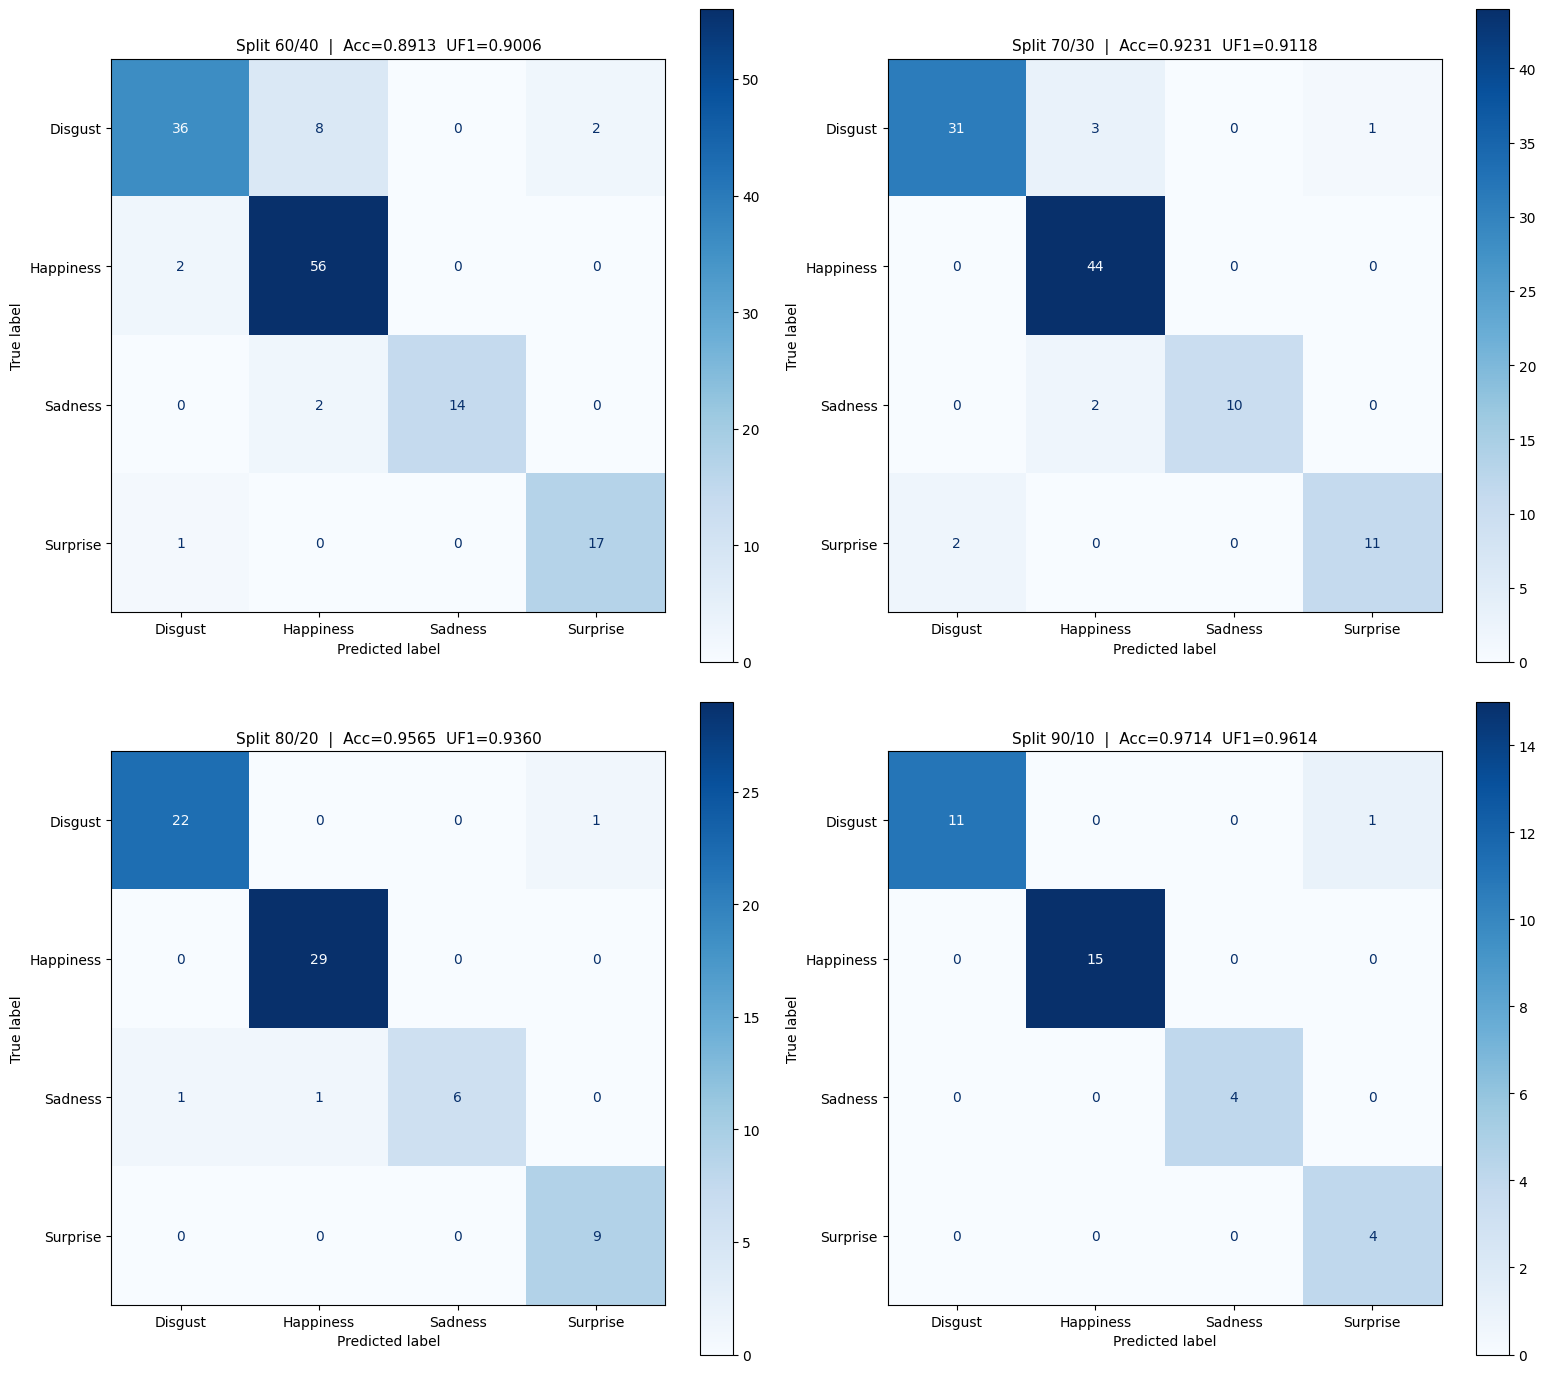

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, r in zip(axes.flatten(), results):
    cm = confusion_matrix(r["y_val"], r["y_val_pred"])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f'Split {r["split"]}  |  Acc={r["val_acc"]:.4f}  UF1={r["val_f1"]:.4f}', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Best Split

In [ ]:
best = max(results, key=lambda r: r["val_f1"])
print(f"Best split: {best['split']} (Val UF1={best['val_f1']:.4f})\n")
print(classification_report(best["y_val"], best["y_val_pred"], target_names=le.classes_))

Best split: 90/10 (Val UF1=0.9614)

              precision    recall  f1-score   support

     Disgust       1.00      0.92      0.96        12
   Happiness       1.00      1.00      1.00        15
     Sadness       1.00      1.00      1.00         4
    Surprise       0.80      1.00      0.89         4

    accuracy                           0.97        35
   macro avg       0.95      0.98      0.96        35
weighted avg       0.98      0.97      0.97        35



## 8. External Test

In [ ]:
y_ext_pred = predict(best["model"], X_ext)

ext_acc = accuracy_score(y_ext, y_ext_pred)
ext_f1 = f1_score(y_ext, y_ext_pred, average="macro")
ext_uar = recall_score(y_ext, y_ext_pred, average="macro")

print(f"External Test — Acc: {ext_acc:.4f}  UF1: {ext_f1:.4f}  UAR: {ext_uar:.4f}")
print(f"\n{classification_report(y_ext, y_ext_pred, target_names=le.classes_)}")

External Test — Acc: 0.2218  UF1: 0.1718  UAR: 0.2989

              precision    recall  f1-score   support

     Disgust       0.20      0.79      0.32       140
   Happiness       0.27      0.38      0.32       160
     Sadness       0.00      0.00      0.00       228
    Surprise       0.26      0.03      0.05       279

    accuracy                           0.22       807
   macro avg       0.18      0.30      0.17       807
weighted avg       0.18      0.22      0.14       807



/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

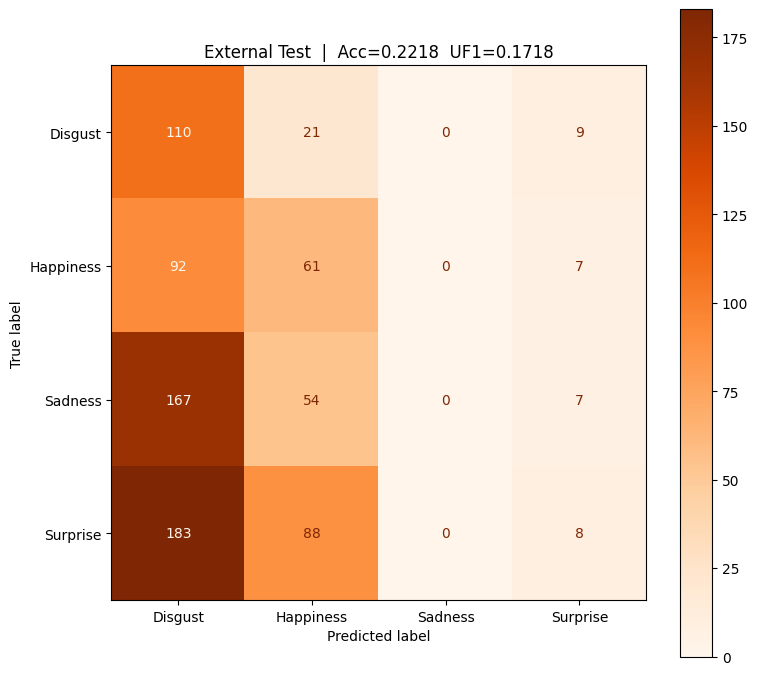

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
cm_ext = confusion_matrix(y_ext, y_ext_pred)
ConfusionMatrixDisplay(cm_ext, display_labels=le.classes_).plot(ax=ax, cmap="Oranges", values_format="d")
ax.set_title(f"External Test  |  Acc={ext_acc:.4f}  UF1={ext_f1:.4f}", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Ringkasan

In [ ]:
summary = pd.DataFrame([{
    "Split": r["split"],
    "PCA": N_COMPONENTS,
    "Train Acc": f'{r["train_acc"]:.4f}',
    "Val Acc": f'{r["val_acc"]:.4f}',
    "Val UF1": f'{r["val_f1"]:.4f}',
    "Val UAR": f'{r["val_uar"]:.4f}',
} for r in results])

summary = pd.concat([summary, pd.DataFrame([{
    "Split": f"External ({best['split']})",
    "PCA": N_COMPONENTS,
    "Train Acc": "-",
    "Val Acc": f"{ext_acc:.4f}",
    "Val UF1": f"{ext_f1:.4f}",
    "Val UAR": f"{ext_uar:.4f}",
}])], ignore_index=True)

print(summary.to_string(index=False))
summary

           Split  PCA Train Acc Val Acc Val UF1 Val UAR
           60/40  196    1.0000  0.8913  0.9006  0.8919
           70/30  196    0.9958  0.9231  0.9118  0.8913
           80/20  196    0.9964  0.9565  0.9360  0.9266
           90/10  196    0.9968  0.9714  0.9614  0.9792
External (90/10)  196         -  0.2218  0.1718  0.2989


,Split,PCA,Train Acc,Val Acc,Val UF1,Val UAR
0,60/40,196,1.0000,0.8913,0.9006,0.8919
1,70/30,196,0.9958,0.9231,0.9118,0.8913
2,80/20,196,0.9964,0.9565,0.9360,0.9266
3,90/10,196,0.9968,0.9714,0.9614,0.9792
4,External (90/10),196,-,0.2218,0.1718,0.2989
